# Lab 5 — Linear Regression Fit (Zomato Ratings)

**Day 02 · Python for Data Science**

## Goals

1. Define features and target; fit OLS with sklearn.
2. Interpret intercept and coefficients.
3. Compare manual vs sklearn predictions.
4. Preview gradient descent and polynomial alternatives.

> **Quick check:** **500** rows · intercept ≈ **3.72** · two coefficients




## Model: ŷ = β₀ + β₁·votes + β₂·cost

In [1]:
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Image, display

GH_ROOT = Path.cwd().resolve()
if GH_ROOT.name == "notebooks":
    GH_ROOT = GH_ROOT.parents[2]
elif (GH_ROOT.parent / "notebooks").is_dir() and (GH_ROOT.parents[1] / "requirements-student.txt").is_file():
    GH_ROOT = GH_ROOT.parents[1]
else:
    for parent in [GH_ROOT, *GH_ROOT.parents]:
        if (parent / "requirements-student.txt").is_file():
            GH_ROOT = parent
            break

ZOMATO_CSV = GH_ROOT / "data" / "zomato" / "zomato_restaurants.csv"
OUTPUT_DIR = GH_ROOT / "hands-on" / "02-python-for-data-science" / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid")

from sklearn.linear_model import LinearRegression

df = pd.read_csv(ZOMATO_CSV)
FEATURES = ["votes", "average_cost_for_two"]
TARGET = "aggregate_rating"

X = df[FEATURES]
y = df[TARGET]
print("X shape:", X.shape, "| y shape:", y.shape)
display(X.head(3))


X shape: (500, 2) | y shape: (500,)


,votes,average_cost_for_two
0,1736,2314
1,828,2368
2,2843,2117


### 1b. Feature distributions (quick EDA)

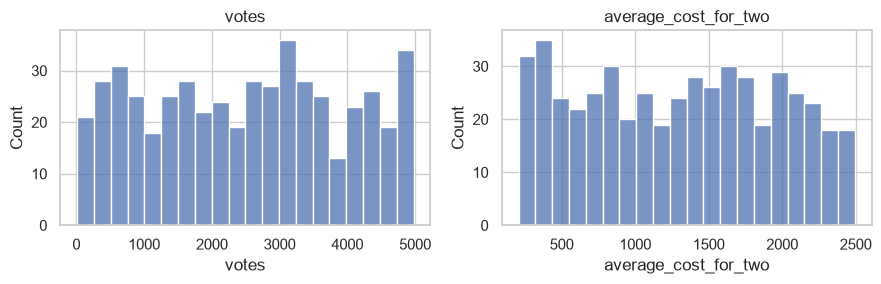

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
sns.histplot(df["votes"], ax=axes[0], bins=20)
axes[0].set_title("votes")
sns.histplot(df["average_cost_for_two"], ax=axes[1], bins=20)
axes[1].set_title("average_cost_for_two")
plt.tight_layout()
plt.show()


---

## 2. Fit OLS on all 500 rows

In [3]:
model = LinearRegression()
model.fit(X, y)
print(f"training rows: {len(df)}")
print(f"intercept (beta_0): {model.intercept_:.4f}")
print("coefficients:", dict(zip(FEATURES, model.coef_.round(6))))
assert len(df) == 500


training rows: 500
intercept (beta_0): 3.7167
coefficients: {'votes': np.float64(1e-06), 'average_cost_for_two': np.float64(-1.7e-05)}


---

## 3. Manual prediction — row 0

In [4]:
row = X.iloc[0]
manual = model.intercept_ + model.coef_[0] * row["votes"] + model.coef_[1] * row["average_cost_for_two"]
sklearn_pred = model.predict(X.head(1))[0]
print("Manual:", round(manual, 4), "| sklearn:", round(sklearn_pred, 4), "| actual:", y.iloc[0])


Manual: 3.6793 | sklearn: 3.6793 | actual: 3.7


---

## 4. Batch predictions

In [5]:
pred3 = model.predict(X.head(3))
comparison = pd.DataFrame({
    "votes": X.head(3)["votes"].values,
    "cost": X.head(3)["average_cost_for_two"].values,
    "actual": y.head(3).values,
    "predicted": pred3.round(2),
})
display(comparison)


,votes,cost,actual,predicted
0,1736,2314,3.7,3.68
1,828,2368,2.7,3.68
2,2843,2117,2.7,3.68


---

## 5. Residuals (in-sample)

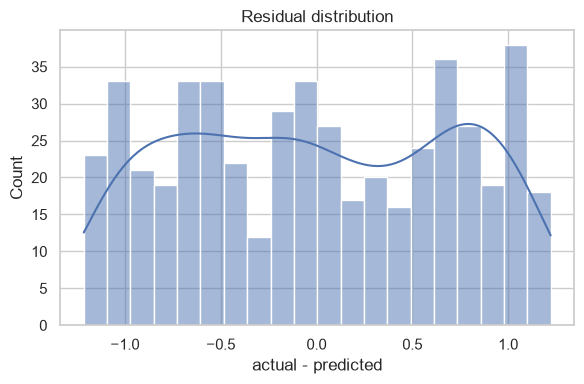

Mean residual (~0): 0.0


In [6]:
y_pred = model.predict(X)
residuals = y - y_pred
fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(residuals, bins=20, kde=True, ax=ax)
ax.set_title("Residual distribution")
ax.set_xlabel("actual - predicted")
plt.tight_layout()
plt.show()
print("Mean residual (~0):", round(residuals.mean(), 4))


### 5b. Predicted vs actual scatter

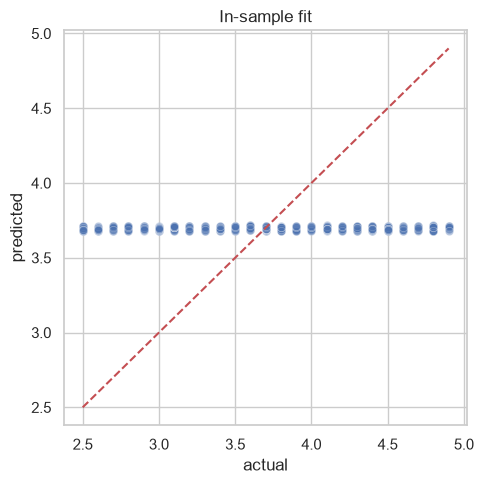

In [7]:
fig, ax = plt.subplots(figsize=(5, 5))
sns.scatterplot(x=y, y=y_pred, ax=ax, alpha=0.4)
ax.plot([y.min(), y.max()], [y.min(), y.max()], "r--")
ax.set_xlabel("actual"); ax.set_ylabel("predicted")
ax.set_title("In-sample fit")
plt.tight_layout()
plt.show()


### 4c. Worst predictions (largest residuals)

In [8]:
res_tbl = pd.DataFrame({"actual": y, "predicted": y_pred.round(2)})
res_tbl["residual"] = res_tbl["actual"] - res_tbl["predicted"]
display(res_tbl.reindex(res_tbl["residual"].abs().nlargest(5).index))


,actual,predicted,residual
121,2.5,3.72,-1.22
482,4.9,3.68,1.22
95,4.9,3.69,1.21
40,2.5,3.71,-1.21
47,2.5,3.71,-1.21


---

## 6. Compare feature sets

In [9]:
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

for name, cols in [("votes only", ["votes"]), ("votes + cost", FEATURES)]:
    Xn = df[cols]
    X_tr, X_te, y_tr, y_te = train_test_split(Xn, y, test_size=0.2, random_state=42)
    m = LinearRegression().fit(X_tr, y_tr)
    print(f"{name:14s} R2 test = {r2_score(y_te, m.predict(X_te)):.4f}")


votes only     R2 test = -0.0035
votes + cost   R2 test = -0.0031


---

## 7. Extended model — add online_order

In [10]:
df_ext = df.copy()
df_ext["online_order_num"] = (df_ext["online_order"] == "Yes").astype(int)
X_ext = df_ext[FEATURES + ["online_order_num"]]
model_ext = LinearRegression().fit(X_ext, y)
for n, c in zip(X_ext.columns, model_ext.coef_):
    print(f"  {n}: {c:.6f}")
print(f"intercept: {model_ext.intercept_:.4f}")


  votes: 0.000000
  average_cost_for_two: -0.000014
  online_order_num: -0.096010
intercept: 3.7640


### 7b. StandardScaler preview (Day 3 link)

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

pipe = make_pipeline(StandardScaler(), LinearRegression())
pipe.fit(X, y)
scaled_model = pipe.named_steps["linearregression"]
print("Coefficients after scaling:", dict(zip(FEATURES, scaled_model.coef_.round(6))))


Coefficients after scaling: {'votes': np.float64(0.001332), 'average_cost_for_two': np.float64(-0.011077)}


---

## 8. Gradient descent (course topic)




In [12]:
import numpy as np

x_raw = df["votes"].to_numpy(dtype=float)
y_vals = df["aggregate_rating"].to_numpy(dtype=float)
x = (x_raw - x_raw.mean()) / x_raw.std()
w, b = 0.0, float(y_vals.mean())
lr, epochs, n = 0.05, 400, len(x)
for _ in range(epochs):
    pred = w * x + b
    err = pred - y_vals
    w -= lr * (2.0 / n) * np.dot(x, err)
    b -= lr * (2.0 / n) * err.sum()

ols = LinearRegression().fit(x.reshape(-1, 1), y_vals)
print(f"GD slope={w:.4f} | OLS slope={ols.coef_[0]:.4f}")
assert abs(w - ols.coef_[0]) < 0.05


GD slope=0.0009 | OLS slope=0.0009


## Linear vs non-linear (course topic)




In [13]:
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

X1 = df[["votes"]]
X_tr, X_te, y_tr, y_te = train_test_split(X1, y, test_size=0.2, random_state=42)
lin = LinearRegression().fit(X_tr, y_tr)
poly = make_pipeline(PolynomialFeatures(2), LinearRegression()).fit(X_tr, y_tr)
print(f"linear R2 test:     {r2_score(y_te, lin.predict(X_te)):.4f}")
print(f"polynomial R2 test: {r2_score(y_te, poly.predict(X_te)):.4f}")


linear R2 test:     -0.0035
polynomial R2 test: -0.0085


---

## 10. Checkpoint

In [14]:
assert len(df) == 500 and len(model.coef_) == 2
print(f"intercept: {model.intercept_:.4f}")
print(f"coefficients: {model.coef_.round(4)}")
print("\n✓ Checkpoint assertions passed")


intercept: 3.7167
coefficients: [ 0. -0.]

✓ Checkpoint assertions passed
